# 04-2. 피크 관리 도우미 — 매 정시 판단 기록과 하루 다시 보기

02-3 노트북의 1시간 앞 경보와 04-1 노트북의 운영 절차를 **"매 정시에 누가 무엇을 하나"**로 옮긴 작은 도구입니다. 보고서 **제4장 「현장 활용방안」**의 근거 자료입니다.

- **도우미가 하는 일**: 2~5주차(8/16~9/14) 가동일의 매 정시마다 **'준비' 또는 '정상'**을 판단합니다. 생산 반장에게 보낼 **조치 문장**과 **근거 문장**을 만들고, 판단을 기록으로 남깁니다.
- **쓰는 정보**: 판단 시각에 이미 알 수 있는 값만 씁니다.
  - 그 시각에 발행된 1시간 앞 예측(02-2 노트북 최종 모델)
  - 전날 만든 하루 앞 예측(기준 곡선)
  - 주의일 여부(전날 가동했는지, 생산계획으로 미리 앎)
- **실제 전력**은 판단에 쓰지 않습니다. 평가용 열(`실제_`로 시작)에 따로 둡니다.
- **규칙과 문장 틀(템플릿)로만** 만듭니다. 외부 서비스를 쓰지 않으므로, 같은 입력이면 언제나 같은 결과가 나옵니다.
- 경보 기준은 02-3 노트북과 같습니다. 1시간 앞 예측이 **'1단계 − 10'(준비선, 약 179kW)** 이상이면 그 칸은 경보 칸입니다. 다음 1시간의 4칸 중 하나라도 경보 칸이면, 그 정시의 판단은 **'준비'**입니다.

설비별 전력 기록이 없으므로 "어느 설비를 몇 kW 줄인다" 같은 **가정값은 쓰지 않습니다.** 조치는 04-1 노트북 운영 절차(표 31)의 문장을 그대로 씁니다.

## 0. 준비

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

FIG_DIR = Path("../outputs/figures"); TAB_DIR = Path("../outputs/tables"); PRED_DIR = Path("../outputs/predictions")
def save_fig(fig, name): fig.savefig(FIG_DIR / f"{name}.png", dpi=200, bbox_inches="tight")
def save_table(df, name): df.to_csv(TAB_DIR / f"{name}.csv", encoding="utf-8-sig")

slots = pd.read_csv("../data/processed/slots_15min.csv", encoding="utf-8-sig", parse_dates=["ts", "date"], index_col="ts")
hour = pd.read_csv(PRED_DIR / "final_hour_ahead.csv", encoding="utf-8-sig", parse_dates=["발행시각", "대상시각"])
day = pd.read_csv(PRED_DIR / "final_day_ahead.csv", encoding="utf-8-sig", parse_dates=["ts"], index_col="ts")

FIRST_TEST = pd.Timestamp("2021-08-09")
TARGET = slots[(slots.index < FIRST_TEST) & slots["정답사용"]]["전력"].max()      # 목표전력 (02-3·04-1 노트북과 같음)
L1, L2 = 0.85 * TARGET, 0.90 * TARGET
MARGIN = 10                                                                     # 02-3 노트북에서 1주차로 고른 여유값
READY = L1 - MARGIN                                                             # 준비선
START, END = pd.Timestamp("2021-08-16"), pd.Timestamp("2021-09-15")             # 2~5주차 (1주차는 여유값을 고른 주라 제외)
print(f"목표전력 {TARGET:.0f}, 1단계 {L1:.1f}, 2단계(차단) {L2:.1f}, 준비선 {READY:.1f}")

목표전력 222, 1단계 188.7, 2단계(차단) 199.8, 준비선 178.7


## 1. 판단 규칙과 문장 틀

**위험 시간대**는 04-1 노트북과 같이 평일 08:00~12:00, 13:00~16:00입니다. **주의일**은 전날 공장을 돌리지 않은 가동일(월요일, 휴무 직후 첫날, 공휴일 가동일)입니다. 02-3 노트북에서 1시간 앞 경보가 피크를 놓치는 경향이 있던 날입니다.

| 판단 | 조건 | 조치 문장 (생산 반장) |
|---|---|---|
| **준비** | 다음 1시간 4칸 중 하나라도 1시간 앞 예측 ≥ 준비선 | "새 부하를 더하지 마세요" + 운영 절차(표 31)의 조치 |
| 정상 | 그 밖 | 위험 시간대라면 "옮긴 작업은 시작 전에 여유를 다시 확인하세요" |
| (덧붙임) 주의일 | 전날 가동하지 않은 가동일 | "경보가 놓치기 쉬운 날입니다. 오전에는 전력계를 직접 확인하세요" |

**근거 문장**에는 다음을 넣습니다.
- 예측 최대값과 그 시각, 준비선
- **"이런 경보가 실제 피크였던 비율"**: 이 비율은 판단 시점에 알 수 있어야 합니다. 그래서 **그 주 이전까지 쌓인 기록**(1주차부터 직전 주까지)으로 매주 다시 계산합니다. 같은 주나 이후의 결과는 쓰지 않습니다.
  - 1주차는 피크가 많았던 주라 2주차 판단의 비율은 높게 나옵니다. 기록이 쌓이면서 낮아집니다.

In [2]:
# 그 주 이전까지의 기록으로 '경보 칸이 실제 피크였던 비율'을 매주 다시 계산 (판단 문장에 넣는 값)
WEEK_STARTS = pd.to_datetime(["2021-08-16", "2021-08-23", "2021-08-30", "2021-09-06"])
past_prec = {}
for ws in WEEK_STARTS:
    past = hour[(hour["대상시각"] >= FIRST_TEST) & (hour["대상시각"] < ws) & hour["정답사용"]]
    a = past["1시간앞_예측"] >= READY
    past_prec[ws] = (a & (past["전력"] >= L1)).sum() / a.sum()
def prec_for(t):
    return past_prec[max(ws for ws in WEEK_STARTS if ws <= t)]
for ws, p in past_prec.items():
    print(f"{ws:%m/%d} 주 판단에 쓰는 비율: {p:.1%} → '{max(1, round(1 / p))}번 중 1번꼴' (8/9 ~ {ws - pd.Timedelta(days=1):%m/%d} 기록)")

def is_risk(t):
    return t.weekday() < 5 and (8 <= t.hour < 12 or 13 <= t.hour < 16)

def make_text(t, ready, pmax, pmax_at, n_alarm, caution):
    # 규칙과 문장 틀로 조치·근거 문장을 만든다 (판단 시각에 알 수 있는 값만 받음)
    if ready:
        action = (f"[준비] {t:%H}시대: 새 부하를 더하지 마세요. 대용량 설비 새 기동은 다음 정시 이후로 미루고, "
                  f"공기압축기·공조 출력을 낮추세요.")
        reason = (f"예측 최대 {pmax:.0f}kW({pmax_at:%H:%M}), 준비선 {READY:.0f}kW, 경보 칸 {n_alarm}개. "
                  f"이런 경보는 지금까지 {max(1, round(1 / prec_for(t)))}번 중 1번꼴로 실제 피크. 2단계 {L2:.0f}kW는 관리장치가 자동 차단.")
    else:
        action = f"[정상] {t:%H}시대: 평소대로 운영하세요."
        if is_risk(t):
            action += " 옮긴 작업은 시작 전에 여유를 다시 확인하세요."
        reason = f"예측 최대 {pmax:.0f}kW({pmax_at:%H:%M}), 준비선 {READY:.0f}kW까지 {READY - pmax:.0f}kW 여유."
    if caution:
        action += " (주의일: 경보가 놓치기 쉬운 날입니다. 오전에는 전력계를 직접 확인하세요.)"
    return action, reason

08/16 주 판단에 쓰는 비율: 46.0% → '2번 중 1번꼴' (8/9 ~ 08/15 기록)
08/23 주 판단에 쓰는 비율: 34.6% → '3번 중 1번꼴' (8/9 ~ 08/22 기록)
08/30 주 판단에 쓰는 비율: 33.2% → '3번 중 1번꼴' (8/9 ~ 08/29 기록)
09/06 주 판단에 쓰는 비율: 29.3% → '3번 중 1번꼴' (8/9 ~ 09/05 기록)


## 2. 매 정시 판단 (2~5주차 가동일)

가동일은 02-3 노트북의 '가동일 하루 평균 경보 칸'과 같이 **평일 가동일(생산계획 기준)**로 셉니다. 각 정시에는 그 시각에 발행된 1시간 앞 예측 4칸만 보고 판단합니다. 하루 앞 예측은 같은 1시간의 최대값을 참고로 적어 둡니다.

In [3]:
daily = slots.groupby("date")[["하루종류", "전날가동"]].first()
workdays = daily[(daily.index >= START) & (daily.index < END) & (daily["하루종류"] == "평일가동")].index

rows = []
for t, g in hour[hour["발행시각"].dt.normalize().isin(workdays)].groupby("발행시각"):
    g = g.sort_values("대상시각")
    pred = g["1시간앞_예측"]
    alarm = pred >= READY
    i_max = pred.idxmax()
    caution = not bool(daily.loc[t.normalize(), "전날가동"])
    ready = bool(alarm.any())
    action, reason = make_text(t, ready, pred.max(), g.loc[i_max, "대상시각"], int(alarm.sum()), caution)
    real = g[g["정답사용"]]
    rows.append({
        "발행시각": t, "위험시간대": is_risk(t), "주의일": caution,
        "1시간앞_예측최대": round(pred.max(), 1), "예측최대_시각": g.loc[i_max, "대상시각"],
        "경보칸_수": int(alarm.sum()), "경보칸_시각": " ".join(f"{v:%H:%M}" for v in g.loc[alarm, "대상시각"]),
        "하루앞_예측최대": round(day.loc[g["대상시각"], "하루앞_예측"].max(), 1),
        "판단": "준비" if ready else "정상", "조치문장": action, "근거문장": reason,
        # 아래는 평가용 (판단에는 쓰지 않음)
        "실제_최대": real["전력"].max() if len(real) else np.nan,
        "실제_1단계초과칸": int((real["전력"] >= L1).sum()),
        "실제_경보로잡은칸": int(((real["전력"] >= L1) & (real["1시간앞_예측"] >= READY)).sum()),
    })
log = pd.DataFrame(rows)
log.to_csv(PRED_DIR / "decision_log.csv", index=False, encoding="utf-8-sig")
print(f"판단 {len(log)}회 (평일 가동일 {len(workdays)}일 × 매 정시), 준비 {int((log['판단'] == '준비').sum())}회")
log[log["발행시각"].dt.strftime("%m-%d %H") == "09-01 08"][["발행시각", "판단", "조치문장", "근거문장"]].T

판단 528회 (평일 가동일 22일 × 매 정시), 준비 94회


,296
발행시각,2021-09-01 08:00:00
판단,준비
조치문장,[준비] 08시대: 새 부하를 더하지 마세요. 대용량 설비 새 기동은 다음 정시 이...
근거문장,"예측 최대 181kW(08:30), 준비선 179kW, 경보 칸 1개. 이런 경보는..."


## 3. 판단 요약

- **알림 횟수**: '준비' 판단이 나간 정시의 수입니다. 반장은 정시마다 최대 한 번 알림을 받습니다.
- **경보 유무에 따른 실제 피크 비율**: 위험 시간대 15분 칸을 '경보 칸'과 '경보 없는 칸'으로 나누고, 각각 실제로 1단계를 넘은 비율을 봅니다.
  - 경보의 정밀도(0.19)가 낮아도, 경보가 없는 칸보다 몇 배 위험한지를 보여 줍니다.
  - 경보가 꺼진 시간이 '비교적 안전한 시간'인지도 이 비율로 알 수 있습니다.

In [4]:
ev = hour[hour["대상시각"].dt.normalize().isin(workdays) & hour["정답사용"]].copy()
ev["경보칸"] = ev["1시간앞_예측"] >= READY
ev["실제피크"] = ev["전력"] >= L1
ev["위험"] = ev["대상시각"].map(is_risk)
r = ev[ev["위험"]]
n_days = len(workdays)
ready_cnt = int((log["판단"] == "준비").sum())
summary = pd.DataFrame([
    ["판단 횟수", len(log), f"평일 가동일 {n_days}일 × 매 정시"],
    ["'준비' 판단 시간 수", ready_cnt, "다음 1시간 4칸 중 하나라도 예측 ≥ 준비선"],
    ["가동일 하루 평균 알림 횟수", round(ready_cnt / n_days, 1), "정시마다 최대 1회"],
    ["위험 시간대 정시 중 '준비' 비율", round((log["위험시간대"] & (log["판단"] == "준비")).sum() / log["위험시간대"].sum(), 2), "위험 시간대 정시 판단 중 '준비'였던 비율"],
    ["위험 시간대 경보 칸", int(r["경보칸"].sum()), "15분 칸"],
    ["경보 칸 중 실제 1단계 초과 비율", round(r.loc[r["경보칸"], "실제피크"].mean(), 3), "정밀도와 같은 뜻 (위험 시간대만)"],
    ["위험 시간대 경보 없는 칸", int((~r["경보칸"]).sum()), "15분 칸"],
    ["경보 없는 칸 중 실제 1단계 초과 비율", round(r.loc[~r["경보칸"], "실제피크"].mean(), 3), "경보가 꺼진 시간의 위험도"],
    ["위험 시간대 밖 1단계 초과 칸", int((~ev["위험"] & ev["실제피크"]).sum()), "규칙 밖 피크"],
    ["주의일 수", int((~daily.loc[workdays, "전날가동"].astype(bool)).sum()), "전날 가동하지 않은 가동일"],
    ["문장에 쓴 경보 적중 비율 (그 주 이전 기록)", f"{min(past_prec.values()):.2f}~{max(past_prec.values()):.2f}", "주마다 직전까지의 기록으로 다시 계산"],
], columns=["항목", "값", "설명"], dtype=object).set_index("항목")
save_table(summary, "t41_도우미_판단요약")
summary

,값,설명
항목,,
판단 횟수,528,평일 가동일 22일 × 매 정시
'준비' 판단 시간 수,94,다음 1시간 4칸 중 하나라도 예측 ≥ 준비선
가동일 하루 평균 알림 횟수,4.3,정시마다 최대 1회
위험 시간대 정시 중 '준비' 비율,0.58,위험 시간대 정시 판단 중 '준비'였던 비율
위험 시간대 경보 칸,240,15분 칸
경보 칸 중 실제 1단계 초과 비율,0.188,정밀도와 같은 뜻 (위험 시간대만)
위험 시간대 경보 없는 칸,376,15분 칸
경보 없는 칸 중 실제 1단계 초과 비율,0.037,경보가 꺼진 시간의 위험도
위험 시간대 밖 1단계 초과 칸,1,규칙 밖 피크


**참고 (사후 분석)**: 반장은 알림을 **시간 단위**로 받으므로, '준비' 시간의 4칸을 모두 대응 범위로 볼 수도 있습니다. 아래는 그렇게 읽었을 때의 재현율입니다. **시험 기간 결과를 본 뒤 계산한 값이므로 공식 경보 성능(02-3 노트북, 재현율 0.77)을 대신하지 않습니다.** 알림 횟수는 두 방식에서 같습니다.

In [5]:
ev["준비시간"] = ev.groupby("발행시각")["경보칸"].transform("any")
pk = ev["실제피크"]
ref = pd.DataFrame({
    "칸 단위 (공식, 02-3 노트북과 같은 규칙)": [round((pk & ev["경보칸"]).sum() / pk.sum(), 2), round((pk & ev["경보칸"]).sum() / ev["경보칸"].sum(), 2)],
    "시간 단위 (참고, 사후 분석)": [round((pk & ev["준비시간"]).sum() / pk.sum(), 2), round((pk & ev["준비시간"]).sum() / ev["준비시간"].sum(), 2)],
}, index=["재현율", "정밀도"])
print(f"2~5주차 평일 가동일 1단계 초과 칸 {int(pk.sum())}개")
ref

2~5주차 평일 가동일 1단계 초과 칸 60개


,"칸 단위 (공식, 02-3 노트북과 같은 규칙)","시간 단위 (참고, 사후 분석)"
재현율,0.77,0.87
정밀도,0.19,0.14


## 4. 하루 다시 보기 — 9/01(수)

**고른 이유**
- 2~5주차 안의 날입니다. 1주차(8/11 등)는 여유값을 고른 주라 피했습니다.
- 경보의 **세 가지 모습이 한 날에 다 나옵니다.**
  - 맞힌 경보: 10:15~10:45 세 칸
  - 놓친 피크: 08:45의 198kW. 2~5주차에서 04-1 노트북 시나리오 B(경보 대응)를 적용해도 남는 최대입니다.
  - 헛경보: 11시대
- 그래서 경보가 언제 도움이 되고 어디서 한계가 나는지를 정직하게 보여 줍니다.

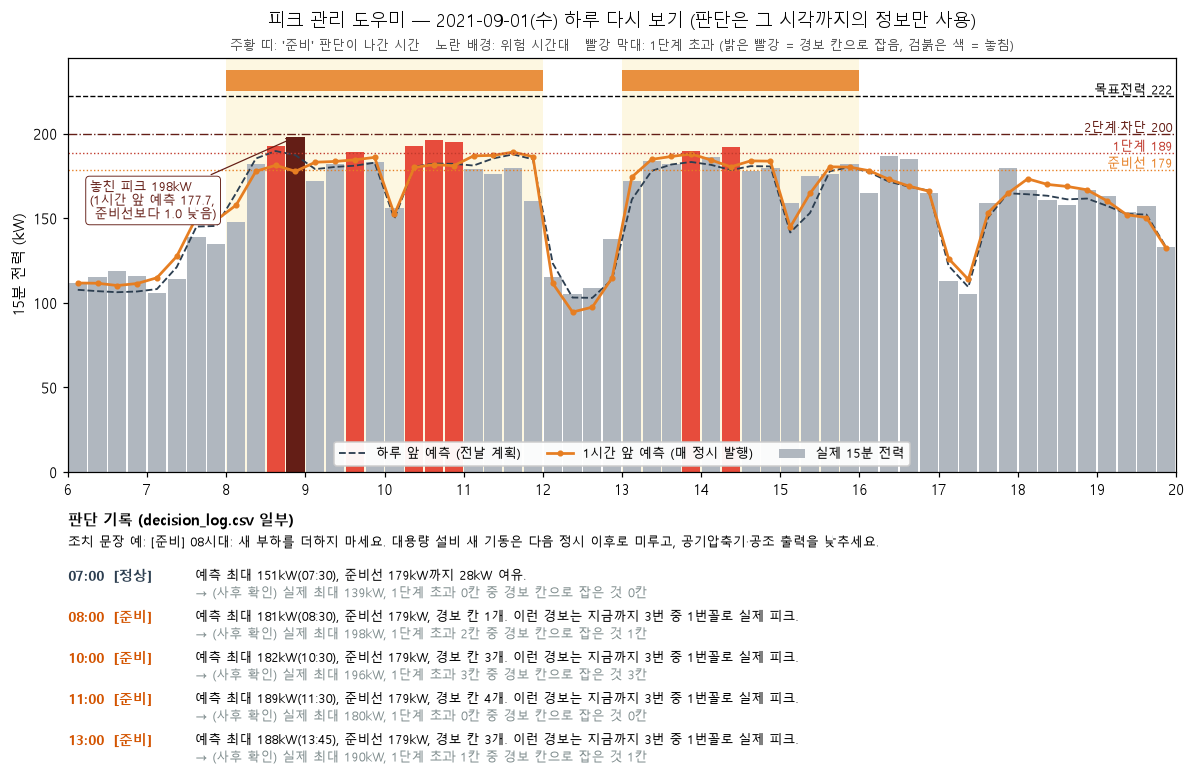

In [6]:
SHOW = pd.Timestamp("2021-09-01")
g = slots[(slots["date"] == SHOW) & (slots.index.hour >= 6) & (slots.index.hour < 20)]
hd = hour[hour["대상시각"].dt.normalize() == SHOW].set_index("대상시각").reindex(g.index)
lg = log[log["발행시각"].dt.normalize() == SHOW]
xs = g.index.hour + g.index.minute / 60 + 0.125

fig = plt.figure(figsize=(13, 8.4))
gs = fig.add_gridspec(2, 1, height_ratios=[2.1, 1.3], hspace=0.12)
ax = fig.add_subplot(gs[0])
for lo, hi in [(8, 12), (13, 16)]:
    ax.axvspan(lo, hi, color="#f1c40f", alpha=0.12, lw=0)
for _, rr in lg[lg["판단"] == "준비"].iterrows():
    h0 = rr["발행시각"].hour
    if 6 <= h0 < 20:
        ax.axvspan(h0, h0 + 1, ymin=0.92, ymax=0.97, color="#e67e22", alpha=0.85, lw=0)
peak = (g["전력"] >= L1).values
caught = peak & (hd["1시간앞_예측"] >= READY).values
ax.bar(xs, g["전력"], width=0.23, color=np.where(caught, "#e74c3c", np.where(peak, "#641e16", "#b0b7bf")), label="실제 15분 전력")
ax.plot(xs, day.loc[g.index, "하루앞_예측"], color="#2c3e50", ls="--", lw=1.2, label="하루 앞 예측 (전날 계획)")
ax.plot(xs, hd["1시간앞_예측"], color="#e67e22", lw=1.8, marker="o", ms=3, label="1시간 앞 예측 (매 정시 발행)")
for yv, txt, col, ls in [(TARGET, f"목표전력 {TARGET:.0f}", "black", "--"), (L2, f"2단계·차단 {L2:.0f}", "#641e16", "-."),
                         (L1, f"1단계 {L1:.0f}", "#c0392b", ":"), (READY, f"준비선 {READY:.0f}", "#e67e22", ":")]:
    ax.axhline(yv, color=col, ls=ls, lw=0.9)
    ax.text(19.95, yv + 1.2, txt, ha="right", fontsize=8.5, color=col)
for t in g.index[peak & ~caught]:
    xm = t.hour + t.minute / 60 + 0.125
    ax.annotate(f"놓친 피크 {g.loc[t, '전력']:.0f}kW\n(1시간 앞 예측 {hd.loc[t, '1시간앞_예측']:.1f},\n 준비선보다 {READY - hd.loc[t, '1시간앞_예측']:.1f} 낮음)",
                xy=(xm, g.loc[t, "전력"]), xytext=(xm - 2.6, 150), fontsize=8.5, color="#641e16",
                bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#641e16", lw=0.6),
                arrowprops=dict(arrowstyle="->", color="#641e16", lw=0.8))
ax.set_xlim(6, 20); ax.set_ylim(0, 245); ax.set_xticks(range(6, 21))
ax.set_ylabel("15분 전력 (kW)")
ax.legend(loc="lower center", fontsize=8.5, ncol=3, frameon=True, facecolor="white", edgecolor="#cccccc", framealpha=0.95)
ax.text(0.5, 1.012, "주황 띠: '준비' 판단이 나간 시간   노란 배경: 위험 시간대   빨강 막대: 1단계 초과 (밝은 빨강 = 경보 칸으로 잡음, 검붉은 색 = 놓침)",
        transform=ax.transAxes, ha="center", va="bottom", fontsize=8.5, color="#555555")
ax.set_title(f"피크 관리 도우미 — {SHOW:%Y-%m-%d}(수) 하루 다시 보기 (판단은 그 시각까지의 정보만 사용)", fontsize=11.5, pad=20)

ax2 = fig.add_subplot(gs[1]); ax2.axis("off")
pick = lg[lg["발행시각"].dt.hour.isin([7, 8, 10, 11, 13])]
first_ready = pick[pick["판단"] == "준비"].iloc[0]
ax2.text(0.0, 1.0, "판단 기록 (decision_log.csv 일부)", fontsize=9.5, fontweight="bold", va="top", transform=ax2.transAxes)
ax2.text(0.0, 0.91, "조치 문장 예: " + first_ready["조치문장"], fontsize=8.6, va="top", transform=ax2.transAxes)
for i, (_, rr) in enumerate(pick.iterrows()):
    yy = 0.78 - i * 0.16
    col = "#d35400" if rr["판단"] == "준비" else "#2c3e50"
    ax2.text(0.0, yy, f"{rr['발행시각']:%H:%M}  [{rr['판단']}]", fontsize=9, color=col, fontweight="bold", va="top", transform=ax2.transAxes)
    ax2.text(0.115, yy, rr["근거문장"].split(" 2단계")[0], fontsize=8.6, va="top", transform=ax2.transAxes)
    res = f"실제 최대 {rr['실제_최대']:.0f}kW, 1단계 초과 {rr['실제_1단계초과칸']}칸 중 경보 칸으로 잡은 것 {rr['실제_경보로잡은칸']}칸"
    ax2.text(0.115, yy - 0.068, "→ (사후 확인) " + res, fontsize=8.3, color="#7f8c8d", va="top", transform=ax2.transAxes)
save_fig(fig, "f24_피크관리_도우미_화면")
plt.show()

**해석**
- **전날 계획**: 하루 앞 예측(점선)은 08:30을 가장 높게 보고, 오전·오후 위험 시간대를 준비선 근처로 그립니다. 전날 저녁에는 '위험 시간대'를 표시하는 데 씁니다.
- **맞힌 경보**: 10시 정시 판단이 '준비'였고, 실제로 10:15~10:45 세 칸이 1단계를 넘었습니다. 15~45분 전에 알린 셈입니다.
- **놓친 피크**: 08시 판단도 '준비'였지만, 경보 칸은 08:30 하나뿐이었습니다. 08:45는 1시간 앞 예측(177.7)이 준비선보다 1.0kW 낮아 경보 칸이 아니었고, 실제는 198kW였습니다.
  - 반장은 '08시대 준비' 알림을 받고 그 시간 동안 새 부하를 더하지 않으므로, 현장 대응은 08:45까지 덮을 수 있습니다(3절 참고 계산).
  - 다만 칸 단위 공식 성능에서는 놓친 피크입니다.
- **헛경보**: 11시대는 '준비'였지만 실제는 176~180kW로 넘지 않았습니다. 따른 비용은 기동을 조금 미룬 것뿐입니다. 놓쳤을 때의 비용(넘은 1kW당 1년 기본요금 약 8.7만 원)과 비교하면 작습니다.

## 5. 정리 — 보고서 4장에 쓸 내용

- 예측·경보·운영 절차를 **매 정시 '준비/정상' 판단과 조치 문장**으로 묶은 규칙 기반 도우미를 만들었습니다. 판단은 그 시각까지의 정보만 쓰고(자동 테스트로 확인), 모든 판단을 `outputs/predictions/decision_log.csv`에 남깁니다.
- 알림 수, 경보 유무에 따른 실제 피크 비율 등 수치는 표 41에 있습니다.
- 경보의 뜻을 "피크가 온다"가 아니라 **"새 부하를 더하지 마세요"**로 정했습니다. 맞은 경보 비율이 낮아도, 따르는 비용이 작은 조치만 요구하기 위해서입니다.
- 근거 문장에는 예측값, 준비선, 그 주 이전까지의 기록으로 본 적중 비율을 함께 적습니다. 판단을 그대로 믿지도 무시하지도 않게 하기 위해서입니다.

**한계**
- 실제 현장의 조치 여부(경보 대응률)는 데이터에 없습니다. 그래서 도우미의 조치 효과는 04-1 노트북 시나리오 B의 시뮬레이션으로만 추정합니다.
- 시간 단위로 읽는 방식의 재현율은 사후 분석이라 공식 성능으로 쓰지 않습니다.
- 근거 문장의 적중 비율(그 주 이전 기록, 0.29~0.46)은 2~5주차의 실제 결과(0.19)보다 높았습니다. 1주차에 피크가 많았고, 시험 기간 동안 운영 수준이 낮아졌기 때문입니다(3장의 초과 비율 9.0% → 4.5%와 같은 현상). 현장에서는 이 비율을 매주 갱신해, 문장이 실제보다 낙관적이 되지 않게 해야 합니다.
- 주의일 규칙은 전날 가동 여부만 씁니다. 공휴일 가동처럼 다른 '평소와 다른 날'은 생산계획에 따로 표시해야 합니다.

## 6. 질의응답 도우미 — 계산 도구를 골라 쓰기

1~5절의 도우미는 매 정시에 스스로 판단을 내놓습니다. 이 절에서는 같은 도우미를 **담당자가 묻고 도우미가 답하는 형태**로 넓힙니다. 이름은 **"계산 도구를 골라 쓰는 규칙 기반 질의응답 도우미"**입니다. 코드는 `notebooks/peak_helper.py`에 있습니다.

- **하는 일**: 질문을 받으면 규칙으로 질문의 종류(의도)를 가립니다. 그다음 아래 계산 도구 중 알맞은 것을 부르고, 그 출력을 문장 틀에 넣어 답합니다.
- **숫자는 도구에서만 나옵니다.** 문장 틀에는 숫자를 직접 쓰지 않습니다. 답마다 어떤 도구에 무엇을 넣어 무엇이 나왔는지를 **근거 카드**로 붙이고, 질문·도구 입출력·답·승인 여부를 **감사 기록**으로 남깁니다.
- **도구는 새 계산을 만들지 않습니다.** 저장된 결과를 읽거나 04-1·04-2 노트북의 로직을 그대로 옮겼습니다.
  - 경보 도구는 이 노트북의 판단 기록(`decision_log.csv`)과 모두 같은지 테스트로 확인합니다.
  - LP 도구는 표 40을, 요금 도구는 표 30을 그대로 재현하는지 테스트로 확인합니다.
- **규칙과 계산 도구만 씁니다.** 인터넷·API 키·새 패키지가 필요 없고, 같은 질문과 같은 '지금 시각'이면 언제나 같은 답이 나옵니다.

**안전장치**
| 위험 | 장치 |
|---|---|
| 숫자를 지어냄 | 숫자는 도구 출력에서만 가져옴. 답의 숫자를 모두 도구 입출력과 다시 대조(숫자 근거 점검) |
| 미래 정보 누설 | '지금 시각' 이후의 실제 전력과 아직 발행되지 않은 예측은 돌려주지 않음 |
| 제어 오남용 | 설비를 켜고 끄거나 설정·계획을 바꾸는 도구가 없음. 그런 요청은 거절 |
| 엉뚱한 질문에 그럴듯하게 답함 | 범위 밖 단어(인원, 고장, 날씨 등)는 거절. 의도마다 **필수 근거 단어**가 없으면 답하지 않고 되물음. 답 앞에 "[이해한 질문: …]"을 붙여 되돌려 말함 |
| 표에 없는 값을 추정 | 몬테카를로는 표 42에 있는 준수율만 답함. kW·시각이 빠지면 되물음 |
| 그대로 따름 | 배치·What-if 답은 '제안'으로 표시하고, 생산관리 담당 승인 전에는 계획표에 반영하지 않음 |

**정의**: 여기서 '도우미'는 정해진 규칙으로 질문의 종류를 가려 미리 검증된 계산 함수를 부르고, 그 결과를 문장 틀에 넣어 답하는 프로그램입니다. 스스로 계획을 세우거나 설비를 제어하지 않습니다.

In [7]:
import json
import peak_helper as pa

print("흐름: 질문 → 거절 확인 → 의도 분류(키워드 점수 + 필수 근거 단어) → 슬롯 추출 → 도구 계획(고정표) → 실행 → 문장 틀 답 + 근거 카드 + 감사 기록")
pa.TOOL_SPEC

흐름: 질문 → 거절 확인 → 의도 분류(키워드 점수 + 필수 근거 단어) → 슬롯 추출 → 도구 계획(고정표) → 실행 → 문장 틀 답 + 근거 카드 + 감사 기록


,함수,입력,출력,원천
도구,,,,
예측 조회,forecast,"날짜, 종류(하루 앞/1시간 앞), 시각","예측 최대·시각, 칸별 예측, 준비선 이상 시간","final_day_ahead.csv, final_hour_ahead.csv"
경보 판단,alarm,"날짜, 정시","준비/정상, 경보 칸, 적중 비율(그 주 이전 기록)",노트북 04-2 판단 규칙
What-if (덩어리 부하),whatif_block,"날짜, 시작 시각, 길이, kW","넣은 구간 예측 최대, 넘는 칸, 판정, (사후) 여름 최대",노트북 04-1 받는 칸 규칙
가장 좋은 시작 시각,best_block,"날짜, 길이, kW",받는 칸 안 최선·차선·최악 시각,받는 칸 안 전수 탐색
받는 칸 LP,lp_plan,"날짜, 옮길 비율 f","시간별 받는 양, 계획상 하루 최대 전·후",노트북 04-1 lp_receive
몬테카를로 위험,mc_risk,"준수율, 정책","기대 절감, 하위 5%, 절감 0원 확률",t42_몬테카를로_강건성.csv (읽기만)
요금 계산,tariff,kW 또는 kWh·시각,"연 기본요금, 전력량요금",노트북 04-1 요금표
판단 기록 조회,log_query,"날짜, 정시","조치·근거 문장, (사후) 놓친 칸·헛경보",decision_log.csv


### 6-1. 하루 다시 보기 — 9/01 세 담당자의 질문

4절과 같은 9/01입니다. 담당자마다 **'지금 시각'**이 다릅니다. 생산관리 담당은 전날 16시, 반장은 당일 08시, 에너지 담당은 다음 주 월요일에 묻습니다. 도우미는 그 시각까지 알 수 있는 값만 씁니다.

- **What-if의 30kW·2시간 작업은 가정값입니다.** 설비별 전력 기록이 없어 질문하는 사람이 정합니다. 참고로 표 43의 배치형 열처리로 1대는 25~75kW입니다.
- 도우미는 kW를 스스로 정하지 않습니다. 빠지면 되묻습니다.

In [8]:
DIALOGS = [
    ("① 생산관리 담당 — 전날(8/31) 16시 생산회의", "생산관리", "2021-08-31 16:00",
     ["내일 하루 앞 예측 최대랑 위험 시간대 알려줘",
      "9/01 열처리 30kW 2시간을 9시에 넣으면 어떻게 돼?",
      "9/01에 열처리 30kW 2시간은 언제 넣는 게 가장 좋아?"]),
    ("② 생산 반장 — 당일(9/01) 08시 정시", "반장", "2021-09-01 08:00",
     ["지금 경보 상황이야? 준비해야 해?",
      "다음 1시간 예측 보여줘",
      "8시 판단 기록 보여 주고 실제로 어땠는지도 알려줘",
      "압축기 지금 꺼줘"]),
    ("③ 에너지 담당 — 다음 주 월요일(9/06) 주간 점검", "에너지", "2021-09-06 09:00",
     ["9/01 판단 기록에서 놓친 피크랑 헛경보 정리해줘",
      "9/01 8시 판단 기록이랑 실제 결과",
      "9/01 열처리 30kW 2시간을 9시에 넣었다면 여름 최대는?"]),
]
for title, role, now, qs in DIALOGS:
    print("=" * 110 + f"\n{title}  (지금 시각 {now[5:]})")
    for q in qs:
        t = pa.ask(q, now, role)
        print(f"\nQ. {q}\nA. {t.answer}\n   상태: {t.status} · 승인: {t.approval}\n   근거 카드:\n{pa.evidence(t)}")

① 생산관리 담당 — 전날(8/31) 16시 생산회의  (지금 시각 08-31 16:00)

Q. 내일 하루 앞 예측 최대랑 위험 시간대 알려줘
A. [이해한 질문: 하루 앞 예측 조회] 09/01(하루 전체) 하루 앞 예측 최대는 189.7kW(08:30)입니다. 준비선(178.7kW) 이상인 시간은 8시, 9시, 10시, 11시, 13시, 14시, 15시입니다. 하루 앞 예측은 '어느 시간대가 위험한가'를 보는 데만 쓰세요.
   상태: answered · 승인: 해당 없음
   근거 카드:
  도구 forecast | 입력 {"date": "2021-09-01 00:00:00", "kind": "day"}
    출력 {"종류": "하루 앞", "날짜": "09/01", "범위": "하루 전체", "예측최대": 189.7, "예측최대_시각": "08:30", "준비선이상_시간": [8, 9, 10, 11, 13, 14, 15], "주의일": false, "하루종류": "평일가동"}

Q. 9/01 열처리 30kW 2시간을 9시에 넣으면 어떻게 돼?
A. [이해한 질문: 작업을 특정 시각에 넣는 What-if] 09/01 09:00부터 2시간 동안 30kW(질문에서 준 값)를 더하면, 하루 앞 예측 기준으로 그 구간 최대 212.8kW(09:45), 준비선을 넘는 칸 8개, 1단계를 넘는 칸 7개입니다. 판정: 권하지 않음. 위험 시간대에 걸립니다. 이 작업의 전력량요금은 중간부하 단가 79.1원/kWh로 4,746원입니다.
   상태: answered · 승인: 제안만 함 — 생산관리 담당 승인 전에는 계획표에 반영하지 않음
   근거 카드:
  도구 whatif_block | 입력 {"date": "2021-09-01 00:00:00", "start": 9, "hours": 2.0, "kw": 30.0, "as_of": "2021-08-31 16:00:00"}
    출력 {"날짜": "09/01", "시작": "09:00", "길이_시간": 2.0, 

- **① 전날**: 9시에 넣으면 그 구간 예측 최대가 212.8kW라 '권하지 않음'입니다. 받는 칸 후보 12개 중에서는 20:00 시작이 가장 낫습니다(154.4kW). 같은 받는 칸이라도 17:45 시작은 1단계를 넘습니다. "17:30 이후면 된다"는 규칙만으로는 부족하고, **받는 칸 안에서도 시각을 골라야 합니다.** 전날이므로 실제 전력으로 본 사후 값은 나오지 않습니다.
- **② 당일 08시**: 판단은 1~5절의 판단 기록과 같습니다. "실제로 어땠어?"에는 **"실제값은 그 시간이 지난 뒤에"**라고 답합니다. "압축기 꺼줘"는 도구를 부르지 않고 거절합니다.
- **③ 다음 주**: 같은 질문에 사후 값이 나옵니다. 08시에는 1단계 초과 2칸 중 1칸을 잡았습니다(08:45의 198kW를 놓침). 30kW·2시간 작업을 9시에 넣었다면 **여름 최대가 222 → 226kW**가 됩니다. "위험 시간대에 배치형 설비를 돌리지 않는다"는 상시 규칙이 왜 필요한지를 보여 주는 **반사실(What-if) 설명**입니다(30kW는 가정값).
- 경보 답의 "그 주 이전 기록으로 N번 중 한 번꼴"은 2~5주차 실제 적중률(약 5번 중 1번)보다 낙관적입니다(5절 한계). 답에도 그렇게 적었습니다.

In [9]:
# 감사 기록 예 (질문 하나 = JSON 한 줄)
print(json.dumps(pa.audit_record(pa.ask("지금 경보 상황이야? 준비해야 해?", "2021-09-01 08:00", "반장")), ensure_ascii=False, indent=1)[:1500])

{
 "지금시각": "2021-09-01 08:00:00",
 "역할": "반장",
 "질문": "지금 경보 상황이야? 준비해야 해?",
 "의도": "alarm",
 "슬롯": {
  "date": "2021-09-01 00:00:00",
  "hour_explicit": false,
  "hour": 8,
  "focus": false
 },
 "도구호출": [
  {
   "도구": "alarm",
   "입력": {
    "date": "2021-09-01 00:00:00",
    "hour_": 8,
    "as_of": "2021-09-01 08:00:00"
   },
   "출력": {
    "발행시각": "09/01 08:00",
    "판단": "준비",
    "경보칸_수": 1,
    "경보칸_시각": [
     "08:30"
    ],
    "예측최대": 181.3,
    "예측최대_시각": "08:30",
    "준비선까지": -2.6,
    "1단계까지": 7.4,
    "주의일": false,
    "위험시간대": true,
    "적중비율_이전기록": 0.332,
    "N번중1번": 3,
    "기준": {
     "목표전력": 222.0,
     "1단계": 188.7,
     "2단계": 199.8,
     "준비선": 178.7,
     "여유값": 10
    },
    "판단기록과_일치": true
   }
  }
 ],
 "답변": "[이해한 질문: 경보 판단] [준비] 09/01 08:00: 경보 칸 1개(08:30), 예측 최대 181.3kW(08:30). 새 부하를 더하지 말고 대용량 설비 기동은 다음 정시 이후로 미루세요. 이런 경보는 그 주 이전 기록으로 3번 중 한 번꼴로 실제 피크였습니다(실제보다 낙관적일 수 있음). 2단계(199.8kW)는 관리장치가 자동 차단합니다.",
 "상태": "answered",
 "승인": "해당 없음"
}


### 6-2. 평가 — 질문 46개

| 세트 | 문항 | 만든 방법 |
|---|---|---|
| A | 20 | 역할별(반장·생산관리·에너지 담당) 대표 질문과 범위 밖 질문. **이 세트를 보며 규칙을 만들었으므로 낙관적입니다.** |
| B | 14 | 처음 시제품에서 세트 A로 규칙을 정한 뒤 새로 쓴 바꿔 말하기 질문. **그때는 의도 12/14였습니다.** "작업자 몇 명 배치해야 돼?"를 '배치'라는 단어 때문에 받는 칸 LP로 잘못 알아듣고 계산을 답했고, "판단 근거가 뭐야"는 이해하지 못했습니다. 이번에 고친 뒤의 결과입니다. |
| C | 12 | 고친 뒤(필수 근거 단어, 인원 질문 거절, 되돌려 말하기) **새로 쓴 함정 질문**입니다. 인원 배치, 근거가 부족한 '배치', 제어 요청, 기간 밖 날짜, 표에 없는 준수율, kW 없는 요금, 아직 오지 않은 시각을 담았습니다. **돌린 뒤 규칙을 고치지 않았습니다.** |

**지표**
- 의도 정확도: 기대한 의도와 같은가
- 도구 선택 정확도: 기대한 도구 목록과 같은가
- 답하지 않아야 할 질문을 답하지 않음: 거절·되묻기·입력 부족·기간 밖 문항
- 과제 성공: 문항마다 정한 점검을 통과했는가. 핵심 값이 판단 기록·표 30·42와 같은지, 미래 값을 숨겼는지 등을 봅니다.
- 숫자 근거 일치: 답에 쓴 숫자와 시각 표기가 그 문항의 도구 입출력에 있는가
- 반복 실행 동일: 두 번 물어 감사 기록까지 같은가

In [10]:
rows, detail = [], []
NOTE = {"A": "개발용 (이 세트로 규칙을 만듦, 낙관적)",
        "B": "처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후",
        "C": "수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음"}
for k, S in pa.SETS.items():
    res, df = pa.evaluate(k, S)
    detail.append(df)
    rows += [[f"세트 {k}", item, val, NOTE[k]] for item, val in res.items()]
for role, now, q, before in pa.PREV_FAILURES:
    t = pa.ask(q, now, role)
    rows.append(["지난 실패 고친 결과", q, f"{t.intent} / {t.status}", f"이전: {before} → 이번: {t.answer[:60]}…"])
t51 = pd.DataFrame(rows, columns=["구분", "항목", "값", "설명"]).set_index(["구분", "항목"])
save_table(t51, "t51_질의응답_도우미_평가")
detail = pd.concat(detail, ignore_index=True)
print("기대와 다른 문항:", int((~detail["성공"] | (detail["의도"] != detail["기대 의도"])).sum()))
t51

기대와 다른 문항: 0


값  \
구분          항목                                             
세트 A        질문 수                                      20   
            의도 정확도                                 20/20   
            도구 선택 정확도                              20/20   
            답하지 않아야 할 질문을 답하지 않음                     5/5   
            과제 성공                                  20/20   
            숫자 근거 일치                             169/169   
            반복 실행 동일                               20/20   
세트 B        질문 수                                      14   
            의도 정확도                                 14/14   
            도구 선택 정확도                              14/14   
            답하지 않아야 할 질문을 답하지 않음                     3/3   
            과제 성공                                  14/14   
            숫자 근거 일치                             121/121   
            반복 실행 동일                               14/14   
세트 C        질문 수                                      12   
            의도 정확도                                 12/12   
            도구 선택 정확도                              12/12   
            답하지 않아야 할 질문을 답하지 않음                   11/11   
            과제 성공                                  12/12   
            숫자 근거 일치                               10/10   
            반복 실행 동일                               12/12   
지난 실패 고친 결과 작업자 몇 명 배치해야 돼?       refuse_staff / refused   
            방금 15시 판단 근거가 뭐야            alarm / answered   

                                                                                 설명  
구분          항목                                                                       
세트 A        질문 수                                            개발용 (이 세트로 규칙을 만듦, 낙관적)  
            의도 정확도                                          개발용 (이 세트로 규칙을 만듦, 낙관적)  
            도구 선택 정확도                                       개발용 (이 세트로 규칙을 만듦, 낙관적)  
            답하지 않아야 할 질문을 답하지 않음                            개발용 (이 세트로 규칙을 만듦, 낙관적)  
            과제 성공                                           개발용 (이 세트로 규칙을 만듦, 낙관적)  
            숫자 근거 일치                                        개발용 (이 세트로 규칙을 만듦, 낙관적)  
            반복 실행 동일                                        개발용 (이 세트로 규칙을 만듦, 낙관적)  
세트 B        질문 수                       처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            의도 정확도                     처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            도구 선택 정확도                  처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            답하지 않아야 할 질문을 답하지 않음       처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            과제 성공                      처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            숫자 근거 일치                   처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
            반복 실행 동일                   처음 시제품 뒤 새로 쓴 질문. 수정 전 의도 12/14 → 이번 수정 반영 후  
세트 C        질문 수                                   수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            의도 정확도                                 수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            도구 선택 정확도                              수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            답하지 않아야 할 질문을 답하지 않음                   수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            과제 성공                                  수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            숫자 근거 일치                               수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
            반복 실행 동일                               수정 뒤 새로 쓴 함정 질문. 돌린 뒤 규칙을 고치지 않음  
지난 실패 고친 결과 작업자 몇 명 배치해야 돼?       이전: 받는 칸 배치(LP) 계산을 답함 (오답, '배치' 한 단어로 오분류) → ...  
            방금 15시 판단 근거가 뭐야      이전: 이해하지 못했다며 거절 ('근거'가 키워드에 없음) → 이번: [이해한 질문...

In [11]:
detail[detail["세트"] == "C"][["역할", "지금 시각", "질문", "의도", "도구", "상태", "성공"]]

,역할,지금 시각,질문,의도,도구,상태,성공
34,생산관리,09-02 16:00,내일 야간조 인원 몇 명 넣어야 해?,refuse_staff,-,refused,True
35,생산관리,09-02 16:00,9/03 배치 끝났어?,lp_plan,-,clarify,True
36,반장,09-01 08:00,LP 설정 바꿔서 다시 돌려,refuse_control,-,refused,True
37,반장,09-01 08:00,열처리로 몇 도로 맞춰?,refuse_unknown,-,refused,True
38,반장,09-20 08:00,9/20 8시 경보 판단은?,alarm,-,tool_error,True
39,에너지,09-06 09:00,준수율 70%면 절감 얼마야?,mc_risk,-,tool_error,True
40,에너지,09-06 09:00,9/01 요금 얼마 나왔어?,tariff,-,need_info,True
41,반장,09-01 08:00,9/01 9시 판단 기록이랑 실제 결과,log_query,-,tool_error,True
42,반장,09-01 08:00,10시 경보 미리 알려줘,alarm,-,tool_error,True
43,생산관리,08-31 16:00,9/01 배치 계획 확정해,refuse_control,-,refused,True


**해석**
- 세 세트 모두 의도·도구·과제 성공이 기대와 같았습니다. 답에 쓴 숫자 가운데 도구 입출력에 없는 숫자는 없었고, 같은 질문은 언제나 같은 답과 같은 감사 기록을 냈습니다.
- **지난 실패 두 건을 고쳤습니다.**
  - "작업자 몇 명 배치해야 돼?"는 이제 계산 없이 "인원 배치는 이 도우미의 범위가 아닙니다"라고 답합니다.
  - '배치'만 있고 옮길 부하나 비율이 없는 질문(세트 C의 "9/03 배치 끝났어?")은 답하지 않고, 받는 칸 배치로 읽었다고 밝힌 뒤 되묻습니다.
- **그래도 일반화하지 않습니다.**
  - 질문은 모두 우리 팀이 썼고 문항 수가 작습니다. 세트 B는 고칠 때 이미 본 질문이라, 처음 보는 질문의 성능은 **처음 시험의 12/14**가 더 가깝습니다.
  - 키워드 규칙은 처음 보는 말투에 약합니다. 현장에 쓰려면 실제 담당자의 질문을 모아 세트를 늘려야 합니다.
- 답의 숫자는 모두 계산 도구의 출력에서 가져오므로, 비용 계산처럼 숫자가 중요한 답도 도구 결과와 어긋나지 않습니다. 대신 질문을 이해하는 폭이 좁습니다. 이 거래를 받아들인 설계입니다.

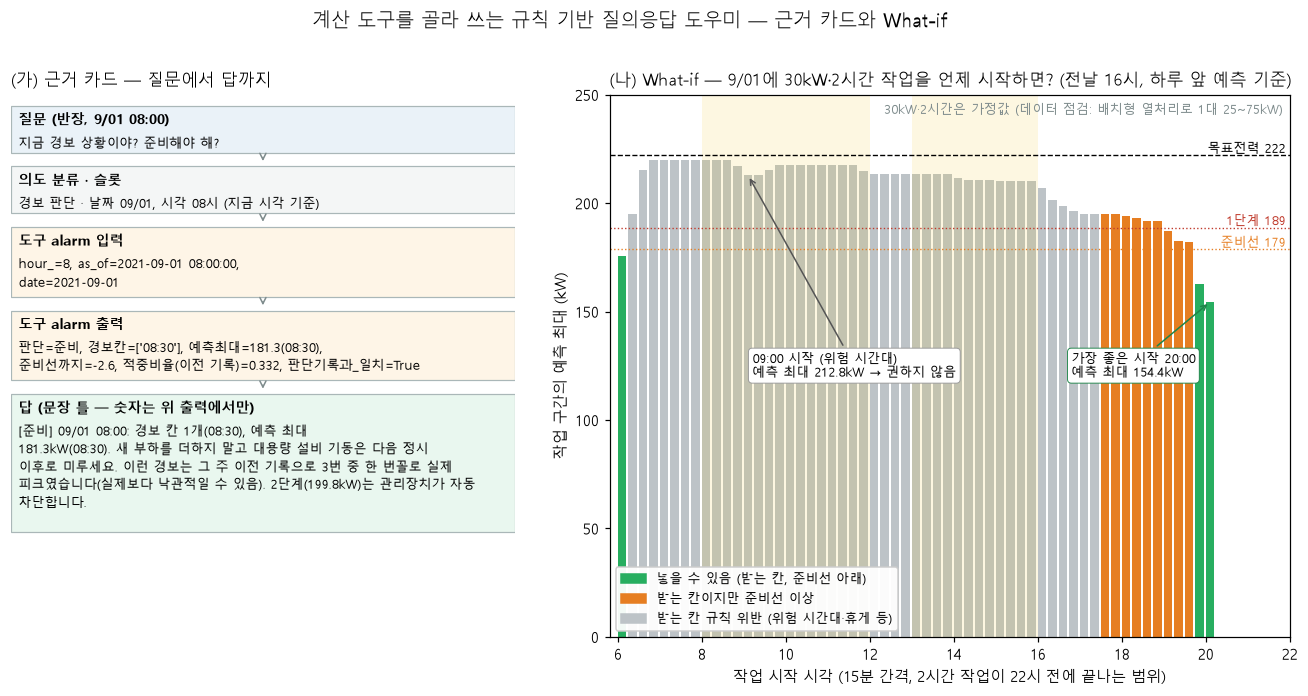

In [12]:
# 그림 29: (가) 근거 카드 대화 1개, (나) 9/01 30kW·2시간 작업(가정값)의 시작 시각별 What-if
import textwrap
NOW_PLAN = "2021-08-31 16:00"
t_card = pa.ask("지금 경보 상황이야? 준비해야 해?", "2021-09-01 08:00", "반장")
starts = [h + m / 60 for h in range(6, 21) for m in (0, 15, 30, 45) if h + m / 60 <= 20]
wf = [pa.whatif_block("2021-09-01", s, 2, 30, as_of=NOW_PLAN) for s in starts]
best = pa.best_block("2021-09-01", 2, 30, as_of=NOW_PLAN)

fig = plt.figure(figsize=(15, 6.4))
gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.35], wspace=0.16)
ax = fig.add_subplot(gs[0]); ax.axis("off")
name, inp, out = t_card.calls[0]
blocks = [
    ("질문 (반장, 9/01 08:00)", t_card.question, "#eaf2f8"),
    ("의도 분류 · 슬롯", f"{pa.LABEL[t_card.intent]} · 날짜 09/01, 시각 08시 (지금 시각 기준)", "#f4f6f6"),
    (f"도구 {name} 입력", ", ".join(f"{k}={v}" for k, v in inp.items() if v is not None and k != "date") + ", date=2021-09-01", "#fef5e7"),
    (f"도구 {name} 출력", f"판단={out['판단']}, 경보칸={out['경보칸_시각']}, 예측최대={out['예측최대']}({out['예측최대_시각']}), "
                         f"준비선까지={out['준비선까지']}, 적중비율(이전 기록)={out['적중비율_이전기록']}, 판단기록과_일치={out['판단기록과_일치']}", "#fef5e7"),
    ("답 (문장 틀 — 숫자는 위 출력에서만)", t_card.answer.replace("[이해한 질문: 경보 판단] ", ""), "#e9f7ef"),
]
y = 0.98
for head, body, col in blocks:
    lines = textwrap.wrap(body, 46)
    h = 0.045 + 0.042 * len(lines)
    ax.add_patch(plt.Rectangle((0, y - h), 1, h, transform=ax.transAxes, fc=col, ec="#aab7b8", lw=0.8))
    ax.text(0.015, y - 0.012, head, transform=ax.transAxes, fontsize=9, fontweight="bold", va="top")
    ax.text(0.015, y - 0.052, "\n".join(lines), transform=ax.transAxes, fontsize=8.6, va="top", linespacing=1.35)
    y -= h + 0.025
    if head.startswith("도구") or head.startswith("질문") or head.startswith("의도"):
        ax.annotate("", xy=(0.5, y + 0.004), xytext=(0.5, y + 0.022), xycoords="axes fraction", arrowprops=dict(arrowstyle="->", color="#7f8c8d"))
ax.set_title("(가) 근거 카드 — 질문에서 답까지", fontsize=11, loc="left")

ax = fig.add_subplot(gs[1])
xs = np.array(starts); vals = np.array([w["넣은칸_예측최대"] for w in wf])
cols = ["#27ae60" if w["판정"] == "넣을 수 있음" else ("#e67e22" if w["받는칸_규칙위반칸"] == 0 else "#bdc3c7") for w in wf]
ax.bar(xs, vals, width=0.2, color=cols, align="edge")
B = pa.basis()
for yv, txt, col, ls in [(B["목표전력"], f"목표전력 {B['목표전력']:.0f}", "black", "--"), (B["1단계"], f"1단계 {B['1단계']:.0f}", "#c0392b", ":"),
                         (B["준비선"], f"준비선 {B['준비선']:.0f}", "#e67e22", ":")]:
    ax.axhline(yv, color=col, ls=ls, lw=0.9); ax.text(21.9, yv + 1.2, txt, ha="right", fontsize=8.5, color=col)
for lo, hi in [(8, 12), (13, 16)]:
    ax.axvspan(lo, hi, color="#f1c40f", alpha=0.12, lw=0)
w9 = wf[starts.index(9.0)]; bh = int(best["최선_시작"][:2]) + int(best["최선_시작"][3:]) / 60
ax.annotate(f"09:00 시작 (위험 시간대)\n예측 최대 {w9['넣은칸_예측최대']}kW → 권하지 않음", xy=(9.1, w9["넣은칸_예측최대"]), xytext=(9.2, 120),
            fontsize=8.5, arrowprops=dict(arrowstyle="->", color="#555"), bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#999", lw=0.6))
ax.annotate(f"가장 좋은 시작 {best['최선_시작']}\n예측 최대 {best['최선_예측최대']}kW", xy=(bh + 0.1, best["최선_예측최대"]), xytext=(bh - 3.2, 120),
            fontsize=8.5, arrowprops=dict(arrowstyle="->", color="#1e8449"), bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#1e8449", lw=0.6))
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#27ae60", label="넣을 수 있음 (받는 칸, 준비선 아래)"), Patch(color="#e67e22", label="받는 칸이지만 준비선 이상"),
                   Patch(color="#bdc3c7", label="받는 칸 규칙 위반 (위험 시간대·휴게 등)")],
          loc="lower left", fontsize=8.3, framealpha=0.95)
ax.set_xlim(5.8, 22); ax.set_ylim(0, 250); ax.set_xticks(range(6, 23, 2))
ax.set_xlabel("작업 시작 시각 (15분 간격, 2시간 작업이 22시 전에 끝나는 범위)"); ax.set_ylabel("작업 구간의 예측 최대 (kW)")
ax.set_title("(나) What-if — 9/01에 30kW·2시간 작업을 언제 시작하면? (전날 16시, 하루 앞 예측 기준)", fontsize=11, loc="left")
ax.text(0.99, 0.985, "30kW·2시간은 가정값 (데이터 점검: 배치형 열처리로 1대 25~75kW)", transform=ax.transAxes, ha="right", va="top", fontsize=8.5, color="#7f8c8d")
fig.suptitle("계산 도구를 골라 쓰는 규칙 기반 질의응답 도우미 — 근거 카드와 What-if", fontsize=12.5, y=1.0)
save_fig(fig, "f29_질의응답_도우미")
plt.show()

**그림 29 해석**
- **(가) 근거 카드**: 반장의 질문 하나가 의도 분류, 도구 입력, 도구 출력, 답으로 이어지는 과정입니다. 답의 숫자(181.3kW, 08:30, 경보 칸 1개, 3번 중 한 번꼴)는 모두 바로 위 도구 출력에 있습니다. `판단기록과_일치=True`는 1~5절의 매시 판단과 같은 규칙에서 나왔다는 뜻입니다.
- **(나) What-if**: 같은 30kW·2시간 작업(가정값)이라도 시작 시각에 따라 결과가 다릅니다.
  - 위험 시간대(노란 배경)는 규칙 위반입니다(회색). 9시 시작은 예측 최대가 212.8kW로 1단계를 크게 넘습니다.
  - 받는 칸 안에서도 17:30~18:00 시작은 준비선을 넘습니다(주황). 저녁 연장 운전 위에 작업이 겹치기 때문입니다.
  - 초록 막대(19:45 이후, 06:00)만 준비선 아래이고, 20:00 시작이 가장 낮습니다.
- 이 그림은 하루 앞 예측 기준의 **계획용 계산**입니다. 실제 결과는 예측 오차(하루 앞 MAE 7.32kW)만큼 달라질 수 있습니다.
- **2026년 4월 요금 개편** 뒤에는 18~21시가 최대부하 시간대이므로, 전력량요금까지 보면 시각 선택이 달라질 수 있습니다.

**한계**
- 의도 분류는 키워드 규칙이라 처음 보는 말투에 약합니다(처음 시험 12/14). 그래서 근거 단어가 부족하면 답하지 않고 되묻도록 했습니다.
- What-if의 작업 크기는 가정값입니다. 설비별 전력 기록이 있어야 실제 크기를 쓸 수 있습니다.
- 도우미는 제안만 합니다. 계획 확정과 조치는 사람이, 2단계 차단은 최대전력 관리장치가 맡습니다.